# Evaluation and baselines

How to decide whether a forecast is *actually* good. The number you get from `r2_score` is the start of the investigation, not the end.

What's in here
- Naive baselines every model must beat (last value, same hour yesterday / last week, seasonal mean)
- Single chronological split vs a monthly **walk-forward** refit loop
- Metrics: RMSE, MAE, MAPE (and how it breaks), sMAPE, MASE, directional accuracy, in-sample vs out-of-sample R² (why it can go negative)
- Error decomposition by hour / dow / month / regime, rolling RMSE
- Comparing two models: Diebold-Mariano style test with an autocorrelation-aware standard error
- Empirical prediction intervals and their coverage
- "R² improved after my change, does that prove it?"
- Statistical vs economic evaluation for prices (a toy trading rule)
- Evaluation checklist

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).sort_values("time")
d = df.set_index("time")
print(d.shape, d.index.min(), d.index.max())

(17520, 5) 2022-01-01 00:00:00+00:00 2023-12-31 23:00:00+00:00


## 0. Problem and frame

**Decision at τ−24h, predict consumption at target hour τ.** The frame is indexed by *target time*; every feature is built with a shift ≥ 24 so it was known at decision time.

Test period = calendar year 2023, train = 2022. A whole year of test data lets us look at errors by month and season.

In [2]:
H = 24
y = d["consumption_mwh"]
F = pd.DataFrame({
    "y": y,
    "lag24": y.shift(24),                          # most recent observation at decision time (= same hour yesterday)
    "lag48": y.shift(48),
    "lag168": y.shift(168),                        # same hour last week
    "roll24": y.shift(24).rolling(24).mean(),      # mean of the 24h ending at decision time
    "temp_lag24": d["temp_c"].shift(24),
    "hour": d.index.hour, "dow": d.index.dayofweek, "month": d.index.month,
})
F["hour_sin"], F["hour_cos"] = np.sin(2*np.pi*F["hour"]/24), np.cos(2*np.pi*F["hour"]/24)
F["is_weekend"] = (F["dow"] >= 5).astype(int)
F = F.dropna()

train = F.loc[: "2022-12-31 23:00"]
test  = F.loc["2023-01-01":]
print(len(train), "train rows |", len(test), "test rows")

8592 train rows | 8760 test rows


## 1. Naive baselines

If the model does not clearly beat these, you have learned nothing. For h = 24 "last value" and "same hour yesterday" are the same series; for h = 1 they differ.

**Pitfall:** the seasonal-mean baseline must be computed on **train only** and mapped onto test.

In [3]:
seasonal = train.groupby(["hour", "dow"])["y"].mean().rename("seasonal_mean")
base = pd.DataFrame({
    "last_value / same hour yesterday": test["lag24"],
    "same hour last week": test["lag168"],
    "seasonal mean (hour x dow, train)": test.join(seasonal, on=["hour", "dow"])["seasonal_mean"],
    "train mean (constant)": np.full(len(test), train["y"].mean()),
}, index=test.index)
base.head(3).round(0)

,last_value / same hour yesterday,same hour last week,"seasonal mean (hour x dow, train)",train mean (constant)
time,,,,
2023-01-01 00:00:00+00:00,26978.0,28713.0,24012.0,29348.0
2023-01-01 01:00:00+00:00,25950.0,27636.0,22846.0,29348.0
2023-01-01 02:00:00+00:00,25329.0,27406.0,22226.0,29348.0


## 2. Metrics in one function

- **RMSE** punishes big misses; same units as y. **MAE** is robust, easier to explain.
- **MAPE** divides by the actual: undefined at 0, explodes near 0, asymmetric. Fine for consumption (always ≫ 0), *not* for prices.
- **sMAPE** bounded in [0, 200%], still ugly near zero.
- **MASE** = MAE / MAE of the naive forecast on train. < 1 means "better than naive"; scale-free, so comparable across series.
- **R²** = 1 − SSE/SST, with SST around the **test** mean. It is *not* the square of a correlation out of sample and **can be negative**.

In [4]:
def metrics(y_true, y_pred, naive_mae):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    err = y_true - y_pred
    return pd.Series({
        "RMSE": np.sqrt(np.mean(err**2)),
        "MAE": np.mean(np.abs(err)),
        "MAPE_%": 100*np.mean(np.abs(err/y_true)),
        "sMAPE_%": 100*np.mean(2*np.abs(err)/(np.abs(y_true)+np.abs(y_pred))),
        "MASE": np.mean(np.abs(err))/naive_mae,
        "R2": r2_score(y_true, y_pred),
        "bias": err.mean(),
    })

naive_mae_train = np.mean(np.abs(train["y"] - train["lag24"]))   # scale for MASE, from TRAIN
results = pd.DataFrame({name: metrics(test["y"], col, naive_mae_train) for name, col in base.items()}).T
results.round(3)

,RMSE,MAE,MAPE_%,sMAPE_%,MASE,R2,bias
last_value / same hour yesterday,1695.799,1333.162,4.647,4.642,0.945,0.835,-1.647
same hour last week,1587.275,1236.283,4.320,4.302,0.876,0.855,-10.024
"seasonal mean (hour x dow, train)",2115.327,1790.646,6.331,6.282,1.269,0.743,-124.296
train mean (constant),4172.469,3375.742,12.253,11.746,2.392,-0.001,-124.395


Note the **negative R²** for the constant train mean: the 2023 mean is lower than 2022's (demand trend), so a constant does worse than the test mean would. Negative OOS R² is a *statement about the test mean*, not a bug in `r2_score`.

## 3. Single split vs walk-forward

A single split trains once and predicts a whole year — by December the model is 12 months stale. **Walk-forward**: refit at the start of each month on everything before it, predict that month. Closer to how a model is run in production, and it produces one out-of-sample prediction per test row.

In [5]:
features = ["lag24", "lag48", "lag168", "roll24", "temp_lag24", "hour_sin", "hour_cos", "is_weekend"]

# (a) single chronological split
m_single = LinearRegression().fit(train[features], train["y"])
pred_single = pd.Series(m_single.predict(test[features]), index=test.index, name="LR single split")

# (b) walk-forward, monthly refit on an expanding window
preds = []
for month_start in pd.date_range("2023-01-01", "2023-12-01", freq="MS", tz="UTC"):
    month_end = month_start + pd.offsets.MonthEnd(1) + pd.Timedelta(hours=23)
    tr = F.loc[: month_start - pd.Timedelta(hours=1)]      # everything strictly before the month
    te = F.loc[month_start: month_end]
    m = LinearRegression().fit(tr[features], tr["y"])
    preds.append(pd.Series(m.predict(te[features]), index=te.index))
pred_wf = pd.concat(preds).rename("LR walk-forward monthly")
print("walk-forward rows:", len(pred_wf), "| same index as test:", pred_wf.index.equals(test.index))

models = pd.concat([base, pred_single, pred_wf], axis=1)
results = pd.DataFrame({name: metrics(test["y"], col, naive_mae_train) for name, col in models.items()}).T
results.round(3).sort_values("RMSE")

walk-forward rows: 8760 | same index as test: True


,RMSE,MAE,MAPE_%,sMAPE_%,MASE,R2,bias
LR single split,1190.281,946.680,3.318,3.299,0.671,0.919,-72.256
LR walk-forward monthly,1190.851,947.852,3.320,3.304,0.672,0.918,-51.756
same hour last week,1587.275,1236.283,4.320,4.302,0.876,0.855,-10.024
last_value / same hour yesterday,1695.799,1333.162,4.647,4.642,0.945,0.835,-1.647
"seasonal mean (hour x dow, train)",2115.327,1790.646,6.331,6.282,1.269,0.743,-124.296
train mean (constant),4172.469,3375.742,12.253,11.746,2.392,-0.001,-124.395


**Interview check:** "Is the gap between train and test large enough?" With h = 24 the first test decision is made at 2022-12-31 00:00 using data up to that hour; the last training *target* is 2022-12-31 23:00, which is **after** that decision time. Strictly you should drop the last 24 training rows (a gap of h). It rarely changes the number, but knowing it does.

## 4. In-sample vs out-of-sample

Always report both. A large gap = overfitting or regime change; identical numbers on a flexible model = suspicious.

In [6]:
def gap_report(model, cols):
    m = model.fit(train[cols], train["y"])
    return pd.Series({"R2_in_sample": r2_score(train["y"], m.predict(train[cols])),
                      "R2_out_of_sample": r2_score(test["y"], m.predict(test[cols]))})

rng = np.random.default_rng(0)
noise_cols = [f"noise{i}" for i in range(20)]
for c in noise_cols:
    F[c] = rng.normal(size=len(F))
train, test = F.loc[: "2022-12-31 23:00"], F.loc["2023-01-01":]

def gap_report_small(cols, n_train=300):
    tr_small = train.iloc[-n_train:]
    m = LinearRegression().fit(tr_small[cols], tr_small["y"])
    return pd.Series({"R2_in_sample": r2_score(tr_small["y"], m.predict(tr_small[cols])),
                      "R2_out_of_sample": r2_score(test["y"], m.predict(test[cols]))})

pd.DataFrame({
    "8.6k rows: real features": gap_report(LinearRegression(), features),
    "8.6k rows: real + 20 noise": gap_report(LinearRegression(), features + noise_cols),
    "300 rows:  real features": gap_report_small(features),
    "300 rows:  real + 20 noise": gap_report_small(features + noise_cols),
}).T.round(4)

,R2_in_sample,R2_out_of_sample
8.6k rows: real features,0.9226,0.9185
8.6k rows: real + 20 noise,0.9228,0.9183
300 rows: real features,0.8876,0.6245
300 rows: real + 20 noise,0.8960,0.6166


In-sample R² **can only go up** when you add a feature, even pure noise; out-of-sample it goes down. With 8,600 rows and 20 noise columns the damage is tiny; with 300 rows (a few weeks of data, or a rare regime) the in-sample number looks better and the out-of-sample one is clearly worse. Whoever shows you an in-sample improvement has shown you nothing.

## 5. Where are the errors? Decompose before you conclude

A single RMSE hides structure. Group the error by hour, day-of-week, month and by *regime*. Systematic bias in a group = a missing feature or a wrong functional form.

In [7]:
ev = test[["y", "hour", "dow", "month", "temp_lag24"]].copy()
ev["pred"] = pred_wf
ev["err"] = ev["y"] - ev["pred"]            # positive = model under-predicts

def by(col):
    g = ev.groupby(col, observed=True)["err"]
    return pd.DataFrame({"bias": g.mean(), "rmse": (g.apply(lambda e: np.sqrt(np.mean(e**2)))), "n": g.size()})

print("by hour (evening peak under-predicted?)")
print(by("hour").round(0).T.iloc[:2])

by hour (evening peak under-predicted?)
hour      0       1       2       3       4       5       6       7       8       9       10      11      12      13  \
bias  -108.0  -133.0  -131.0  -137.0  -137.0   -95.0    -4.0   101.0   140.0    99.0    38.0   -45.0  -131.0  -214.0   
rmse  1265.0  1256.0  1297.0  1230.0  1236.0  1234.0  1183.0  1190.0  1157.0  1123.0  1089.0  1068.0  1067.0  1118.0   

hour      14      15      16      17      18      19      20      21      22      23  
bias  -256.0  -252.0  -129.0    38.0   128.0   101.0    48.0    -2.0   -65.0   -96.0  
rmse  1169.0  1217.0  1167.0  1201.0  1163.0  1157.0  1188.0  1254.0  1280.0  1233.0  


In [8]:
print("by month")
print(by("month").round(0).T.iloc[:2])
print("\nby day of week")
print(by("dow").round(0).T.iloc[:2])

by month
month      1       2       3       4       5       6      7       8      9       10      11      12
bias    215.0   -31.0   -83.0  -375.0  -296.0  -186.0  137.0    41.0  -93.0     4.0    24.0     9.0
rmse   1378.0  1287.0  1140.0  1490.0  1272.0  1082.0  952.0  1000.0  947.0  1200.0  1223.0  1200.0

by day of week
dow        0       1       2       3       4       5       6
bias   234.0   -66.0  -158.0  -240.0  -164.0   -88.0   116.0
rmse  1179.0  1155.0  1273.0  1166.0  1262.0  1067.0  1220.0


In [9]:
# regime: cold hours vs the rest (heating is non-linear, the linear model cannot bend)
ev["regime"] = pd.cut(ev["temp_lag24"], [-99, 0, 10, 20, 99], labels=["<0C", "0-10C", "10-20C", ">20C"])
by("regime").round(0)

,bias,rmse,n
regime,,,
<0C,116.0,1379.0,536
0-10C,-69.0,1238.0,3911
10-20C,-121.0,1144.0,3744
>20C,362.0,942.0,569


## 6. Error over time: rolling RMSE

Is the performance stable, or does one bad fortnight drive the annual number? Compute RMSE on a rolling window and look for spikes / drift.

worst 14-day window ends: 2023-05-06 03:00:00+00:00  RMSE: 1616


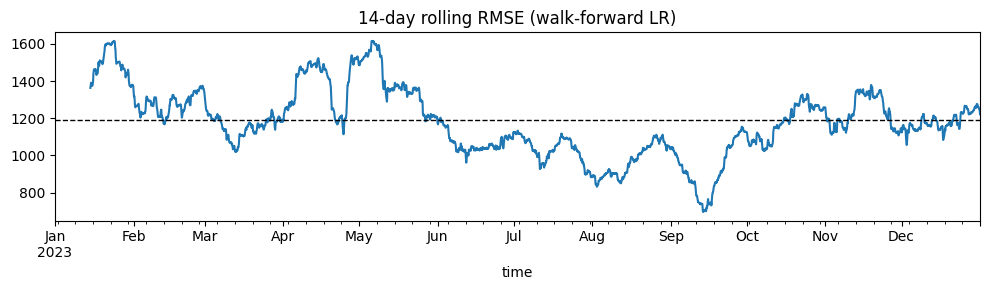

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
roll_rmse = np.sqrt((ev["err"]**2).rolling(24*14).mean())
ax = roll_rmse.plot(figsize=(10, 3), title="14-day rolling RMSE (walk-forward LR)")
ax.axhline(np.sqrt((ev["err"]**2).mean()), color="k", ls="--", lw=1)
plt.tight_layout()
print("worst 14-day window ends:", roll_rmse.idxmax(), " RMSE:", round(roll_rmse.max()))

## 7. Is model B really better than model A? (Diebold–Mariano style)

Take the loss differential per row, `d = e_A² − e_B²`. If B is better, mean(d) > 0. A t-statistic on mean(d) needs a standard error that respects **autocorrelation** in d (hourly errors are correlated), so use a Newey–West (HAC) variance. Ignoring that overstates significance badly.

In [11]:
def nw_se(x, lags):
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    v = np.mean(x**2)
    for k in range(1, lags + 1):
        w = 1 - k / (lags + 1)
        v += 2 * w * np.mean(x[:-k] * x[k:])
    return np.sqrt(v / n)

def dm_test(e_a, e_b, lags=24):
    dd = np.asarray(e_a)**2 - np.asarray(e_b)**2
    naive_t = dd.mean() / (dd.std(ddof=1) / np.sqrt(len(dd)))
    hac_t = dd.mean() / nw_se(dd, lags)
    return pd.Series({"mean_d": dd.mean(), "t_iid": naive_t, "t_HAC": hac_t})

e_naive = test["y"] - test["lag24"]
e_week  = test["y"] - test["lag168"]
e_lr    = test["y"] - pred_wf
pd.DataFrame({
    "naive vs LR":            dm_test(e_naive, e_lr),
    "last week vs LR":        dm_test(e_week, e_lr),
    "single-split vs walk-fwd": dm_test(test["y"] - pred_single, e_lr),
}).T.round(2)

,mean_d,t_iid,t_HAC
naive vs LR,1457607.60,34.51,11.66
last week vs LR,1101315.24,32.41,10.46
single-split vs walk-fwd,-1356.86,-0.90,-0.33


|t| > ~2 is "significant" by rule of thumb. Compare `t_iid` with `t_HAC`: the iid version is inflated by autocorrelation. With a small edge (single-split vs walk-forward) the honest test may say "can't tell".

## 8. Prediction intervals from residual quantiles

Parametric intervals (± 1.96 σ) assume Gaussian, homoscedastic errors — hourly energy errors are neither. Empirical alternative: take the 5th / 95th percentiles of **training** residuals (better: of walk-forward residuals from earlier months) and check **coverage** on test. Coverage far from 90% means the intervals are lying.

In [12]:
resid_train = train["y"] - m_single.predict(train[features])
q_lo, q_hi = resid_train.quantile([0.05, 0.95])
lo, hi = pred_single + q_lo, pred_single + q_hi
covered = (test["y"] >= lo) & (test["y"] <= hi)
print(f"interval = pred + [{q_lo:.0f}, {q_hi:.0f}]   nominal 90%   test coverage {covered.mean():.1%}")

# per-hour quantiles: intervals should be wider where the model is worse
q_by_hour = resid_train.groupby(train["hour"]).quantile([0.05, 0.95]).unstack()
lo_h = pred_single + test["hour"].map(q_by_hour[0.05]).values
hi_h = pred_single + test["hour"].map(q_by_hour[0.95]).values
cov_h = ((test["y"] >= lo_h) & (test["y"] <= hi_h))
print(f"per-hour quantiles: test coverage {cov_h.mean():.1%}")
print("\ncoverage by month (single-split model gets stale):")
print(covered.groupby(test["month"]).mean().round(2).to_frame().T)

interval = pred + [-1975, 1944]   nominal 90%   test coverage 90.1%
per-hour quantiles: test coverage 89.4%

coverage by month (single-split model gets stale):
month    1     2     3    4     5     6     7     8     9     10    11   12
0      0.84  0.87  0.92  0.8  0.89  0.93  0.95  0.96  0.96  0.89  0.89  0.9


## 9. "R² improved after my change — does that prove the change is right?"

No. Ask three questions.
1. **How many things did I try?** If you tried 20 features, the best one looks good by chance (multiple comparisons).
2. **Is it one period driving it?** Compare per-month: does B win most months, or only one?
3. **Does the improvement have a mechanism?** A feature you cannot explain is a feature you cannot trust when the regime changes.

In [13]:
def walk_forward(cols, window_days=None):
    out = []
    for ms in pd.date_range("2023-01-01", "2023-12-01", freq="MS", tz="UTC"):
        me = ms + pd.offsets.MonthEnd(1) + pd.Timedelta(hours=23)
        tr, te = F.loc[: ms - pd.Timedelta(hours=1)], F.loc[ms: me]
        if window_days is not None:
            tr = tr.iloc[-24 * window_days:]                     # rolling window instead of expanding
        out.append(pd.Series(LinearRegression().fit(tr[cols], tr["y"]).predict(te[cols]), index=te.index))
    return pd.concat(out)

pred_A = walk_forward([c for c in features if c != "temp_lag24"])   # A: no temperature
pred_B = pred_wf                                                     # B: with temp_lag24, expanding window
pred_C = walk_forward(features, window_days=30)                      # C: same features, "only recent data is relevant"

def rmse(e): return np.sqrt(np.mean(e**2))
monthly = pd.DataFrame({
    "A: no temp": (test["y"] - pred_A).groupby(test["month"]).apply(rmse),
    "B: + temp_lag24": (test["y"] - pred_B).groupby(test["month"]).apply(rmse),
    "C: B, 30-day window": (test["y"] - pred_C).groupby(test["month"]).apply(rmse),
}).round(0)
monthly["B beats A"] = monthly["B: + temp_lag24"] < monthly["A: no temp"]
monthly["C beats B"] = monthly["C: B, 30-day window"] < monthly["B: + temp_lag24"]
print(monthly)
print("\nB beats A in", monthly["B beats A"].sum(), "of 12 months |  C beats B in", monthly["C beats B"].sum(), "of 12")
print("annual RMSE  A %.0f   B %.0f   C %.0f" % (rmse(test['y']-pred_A), rmse(test['y']-pred_B), rmse(test['y']-pred_C)))

       A: no temp  B: + temp_lag24  C: B, 30-day window  B beats A  C beats B
month                                                                        
1          1571.0           1378.0               1616.0       True      False
2          1398.0           1287.0               1457.0       True      False
3          1150.0           1140.0               1153.0       True      False
4          1615.0           1490.0               1777.0       True      False
5          1296.0           1272.0               1399.0       True      False
6          1050.0           1082.0               1064.0      False       True
7           954.0            952.0                895.0       True       True
8          1019.0           1000.0                941.0       True       True
9          1015.0            947.0                966.0       True      False
10         1238.0           1200.0               1412.0       True      False
11         1281.0           1223.0               1213.0       Tr

B (a feature with a mechanism: heating demand) wins consistently. C ("only use the last 30 days", a plausible-sounding choice) wins *some* months and loses badly in others — the per-month pattern tells you it is unstable, the annual number alone would not.

**Pitfall:** dropping one bad month and re-running until the result looks nice *is* the multiple-comparisons problem.

## 10. Prices: statistical vs economic evaluation

Consumption metrics are all we needed above. For **prices**, MAPE breaks and the question changes from "how close" to "would acting on it have made money".

In [14]:
p = d["price_eur_mwh"]
P = pd.DataFrame({
    "y": p, "p_lag24": p.shift(24), "p_lag48": p.shift(48), "p_lag168": p.shift(168),
    "p_roll24": p.shift(24).rolling(24).mean(),
    "cons_lag24": y.shift(24), "wind_lag24": d["wind_ms"].shift(24),
    "hour_sin": np.sin(2*np.pi*d.index.hour/24), "hour_cos": np.cos(2*np.pi*d.index.hour/24),
    "is_weekend": (d.index.dayofweek >= 5).astype(int), "month": d.index.month,
}).dropna()
ptrain, ptest = P.loc[: "2022-12-31 23:00"], P.loc["2023-01-01":]
pcols = [c for c in P.columns if c not in ("y", "month")]
pm = Ridge(alpha=1.0).fit(ptrain[pcols], ptrain["y"])
ptest = ptest.assign(pred=pm.predict(ptest[pcols]))
ptest["err"] = ptest["y"] - ptest["pred"]

naive_p_mae = np.mean(np.abs(ptrain["y"] - ptrain["p_lag24"]))
pd.DataFrame({"naive lag24": metrics(ptest["y"], ptest["p_lag24"], naive_p_mae),
              "Ridge": metrics(ptest["y"], ptest["pred"], naive_p_mae)}).T.round(2)

,RMSE,MAE,MAPE_%,sMAPE_%,MASE,R2,bias
naive lag24,28.36,20.20,41.34,27.63,1.00,0.33,-0.04
Ridge,23.52,17.17,42.01,22.90,0.85,0.54,-4.38


Ridge beats naive on RMSE, MAE and MASE but has a *worse* MAPE. **MAPE failure:** a handful of near-zero prices dominate the average percentage error. Look at the contribution of the smallest |price| rows.

In [15]:
ape = 100 * np.abs(ptest["err"] / ptest["y"])
order = ptest["y"].abs().sort_values().index
print("MAPE all rows:              %.1f%%" % ape.mean())
print("MAPE excluding 10 smallest |price| rows: %.1f%%" % ape.drop(order[:10]).mean())
print("median APE:                 %.1f%%" % ape.median())
pd.DataFrame({"price": ptest["y"], "pred": ptest["pred"], "APE_%": ape}).loc[order[:5]].round(1)

MAPE all rows:              42.0%
MAPE excluding 10 smallest |price| rows: 32.6%
median APE:                 16.3%


,price,pred,APE_%
time,,,
2023-03-12 08:00:00+00:00,-0.4,97.9,22872.4
2023-09-29 23:00:00+00:00,0.5,66.7,12476.5
2023-07-10 14:00:00+00:00,-0.6,52.5,9155.7
2023-10-26 00:00:00+00:00,-0.8,80.7,10722.6
2023-06-20 22:00:00+00:00,-0.8,76.6,9215.8


**Regime decomposition for prices:** spikes (> 150) are where the money and the risk are, and where a linear model is worst.

In [16]:
ptest["regime"] = pd.cut(ptest["y"], [-1000, 0, 50, 100, 150, 10000], labels=["<0", "0-50", "50-100", "100-150", ">150"])
g = ptest.groupby("regime", observed=True)["err"]
pd.DataFrame({"n": g.size(), "bias": g.mean(), "rmse": g.apply(lambda e: np.sqrt(np.mean(e**2)))}).round(1)

,n,bias,rmse
regime,,,
<0,29,-76.0,81.8
0-50,1349,-23.7,28.5
50-100,4589,-7.1,18.5
100-150,2572,7.0,18.6
>150,221,48.3,70.4


**Directional accuracy:** did we get the sign of the change vs the last known price right? Compare with 50% (coin) and with "always same direction as yesterday's change".

In [17]:
actual_chg = ptest["y"] - ptest["p_lag24"]
pred_chg = ptest["pred"] - ptest["p_lag24"]
dir_acc = (np.sign(actual_chg) == np.sign(pred_chg)).mean()
momentum_acc = (np.sign(actual_chg) == np.sign(ptest["p_lag24"] - ptest["p_lag48"])).mean()
print(f"directional accuracy: model {dir_acc:.3f} | momentum rule {momentum_acc:.3f} | coin 0.500")

directional accuracy: model 0.675 | momentum rule 0.376 | coin 0.500


**Toy economic test.** Rule: when the predicted 24h change exceeds a threshold, take a position in the direction of the prediction; P&L per trade = sign × actual change (EUR/MWh). Compare with random signs on the *same* hours.

This is a **toy**: no bid/ask, no imbalance cost, no volume, and day-ahead prices are not tradable like this. The point is the *method*: benchmark against randomness, look at hit rate and tail, not just the total.

In [18]:
thr = 15
trade = pred_chg.abs() > thr
pnl = np.sign(pred_chg[trade]) * actual_chg[trade]

rng = np.random.default_rng(1)
random_totals = np.array([(rng.choice([-1, 1], trade.sum()) * actual_chg[trade]).sum() for _ in range(2000)])
print(f"trades: {trade.sum()} | hit rate {(pnl > 0).mean():.3f} | mean P&L/trade {pnl.mean():.2f} | total {pnl.sum():.0f}")
print(f"random-sign totals: mean {random_totals.mean():.0f}, sd {random_totals.std():.0f}  ->  model total is "
      f"{(pnl.sum() - random_totals.mean()) / random_totals.std():.1f} sd above random")
print("\nP&L per trade quantiles:", pnl.quantile([.01, .1, .5, .9, .99]).round(1).to_dict())
print("share of total P&L from the 10 best trades: %.0f%%" % (100 * pnl.nlargest(10).sum() / pnl.sum()))

trades: 2824 | hit rate 0.822 | mean P&L/trade 21.36 | total 60314
random-sign totals: mean -29, sd 1945  ->  model total is 31.0 sd above random

P&L per trade quantiles: {0.01: -31.1, 0.1: -7.2, 0.5: 19.7, 0.9: 48.5, 0.99: 140.2}
share of total P&L from the 10 best trades: 4%


This is synthetic data with a very regular price process, so the numbers are absurdly good — treat them as a demonstration of the *procedure*.

**Interview check:** "What would kill this in practice?" → transaction/imbalance costs vs mean P&L per trade, P&L concentrated in a few spike hours, the model was fit on 2022 (gas crisis regime) and evaluated on 2023, no position sizing.

## 11. Evaluation checklist

1. Did I compare with **naive baselines** (last value, seasonal naive, seasonal mean)? By how much do I beat them — and is that within noise?
2. Is the split **chronological**, with a **gap ≥ h**? Is the test period long enough to cover seasons / regimes?
3. Do I report **out-of-sample** numbers? What is the in-sample vs OOS gap?
4. Is the metric appropriate for the **scale and sign** of the target (MAPE near zero, R² with trend)?
5. **Where** are the errors: by hour, weekday, month, regime? Any systematic **bias** in a group?
6. Is the error **stable over time** (rolling RMSE), or is one period driving the annual number?
7. When comparing two models, is the difference **significant** with an autocorrelation-aware test? Does B win **most sub-periods**?
8. **How many variants** did I try before this one? (Multiple comparisons.)
9. Does the improvement have a **mechanism** I can explain?
10. Are prediction intervals **calibrated** (coverage on test ≈ nominal)?
11. For trading: **economic** evaluation vs random, costs, concentration of P&L, regime dependence.
12. Would I be comfortable if this number were **worse tomorrow**? If not, I have not understood why it is what it is.